# QP Solvers & CVXPY — Dose Rate Comparison (7 detectors)

Compares all available qpsolvers and cvxpy solvers across 7 detector types
on the IAEA Compendium dataset (251 spectra).

**Detectors**: GSF, PTB, LANL, JINR, FERMILAB, EURADOS (20 MeV max), IHEP

**QPSolvers** (8): clarabel, ecos, highs, osqp, piqp, proxqp, qpalm, scs

**CVXPY** (10): CLARABEL, ECOS, ECOS_BB, HIGHS, OSQP, PIQP, PROXQP, QPALM, SCIPY, SCS

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

In [2]:
RESULTS_CSV = Path('..') / 'tests' / 'qpsolvers_cvxpy_dose_rate_results.csv'

if not RESULTS_CSV.exists():
    raise FileNotFoundError(
        f'{RESULTS_CSV} not found. Run: uv run python tests/dose_rate_qpsolvers_cvxpy.py'
    )

df = pd.read_csv(RESULTS_CSV)
ok = df[df['status'] == 'OK']
print(f'Total records: {len(df)}  |  OK: {len(ok)}  |  ERROR: {len(df) - len(ok)}')
print(f'Detectors: {sorted(ok["detector"].unique())}')
print(f'QPSolvers: {sorted(ok[ok["solver_type"]=="qpsolvers"]["solver_name"].unique())}')
print(f'CVXPY: {sorted(ok[ok["solver_type"]=="cvxpy"]["solver_name"].unique())}')
print(f'Spectra: {ok["place"].nunique()}')

Total records: 189756  |  OK: 189756  |  ERROR: 0
Detectors: ['EURADOS', 'FERMILAB', 'GSF', 'IHEP', 'JINR', 'LANL', 'PTB']
QPSolvers: ['clarabel', 'ecos', 'highs', 'osqp', 'piqp', 'proxqp', 'qpalm', 'scs']
CVXPY: ['CLARABEL', 'ECOS', 'ECOS_BB', 'HIGHS', 'OSQP', 'PIQP', 'PROXQP', 'QPALM', 'SCIPY', 'SCS']
Spectra: 251


In [3]:
DETECTOR_COLORS = {
    'GSF': '#e41a1c',
    'PTB': '#377eb8',
    'LANL': '#4daf4a',
    'JINR': '#984ea3',
    'FERMILAB': '#ff7f00',
    'EURADOS': '#a65628',
    'IHEP': '#f781bf',
}

def fit_angle(xs, ys):
    xs, ys = np.asarray(xs, float), np.asarray(ys, float)
    m = (xs > 0) & (ys > 0) & np.isfinite(xs) & np.isfinite(ys)
    xs, ys = xs[m], ys[m]
    if len(xs) < 3:
        return np.nan, np.nan, 'N/A'
    k = float(np.sum(xs * ys) / np.sum(xs ** 2))
    theta = float(np.degrees(np.arctan(k)))
    d = abs(theta - 45.0)
    cls = 'Excellent' if d < 1 else 'Good' if d < 5 else 'Fair' if d < 10 else 'Poor'
    return k, theta, cls

def plot_scatter(ax, xs, ys, color, label, alpha=0.4):
    ax.scatter(xs, ys, c=color, s=12, alpha=alpha, edgecolors='none', label=label)

def add_diagonal(ax, k=None):
    lims = ax.get_xlim()
    line_x = np.logspace(np.log10(lims[0]), np.log10(lims[1]), 100)
    ax.plot(line_x, line_x, 'k--', lw=1, alpha=0.4, label='45°')
    if k is not None and np.isfinite(k):
        ax.plot(line_x, k * line_x, 'r-', lw=1.2, alpha=0.6, label=f'k={k:.3f}')

---
## 1. QPSolvers — All Solvers × All Detectors

ISO dose scatter plots for each qpsolvers solver. Colors = detector types.

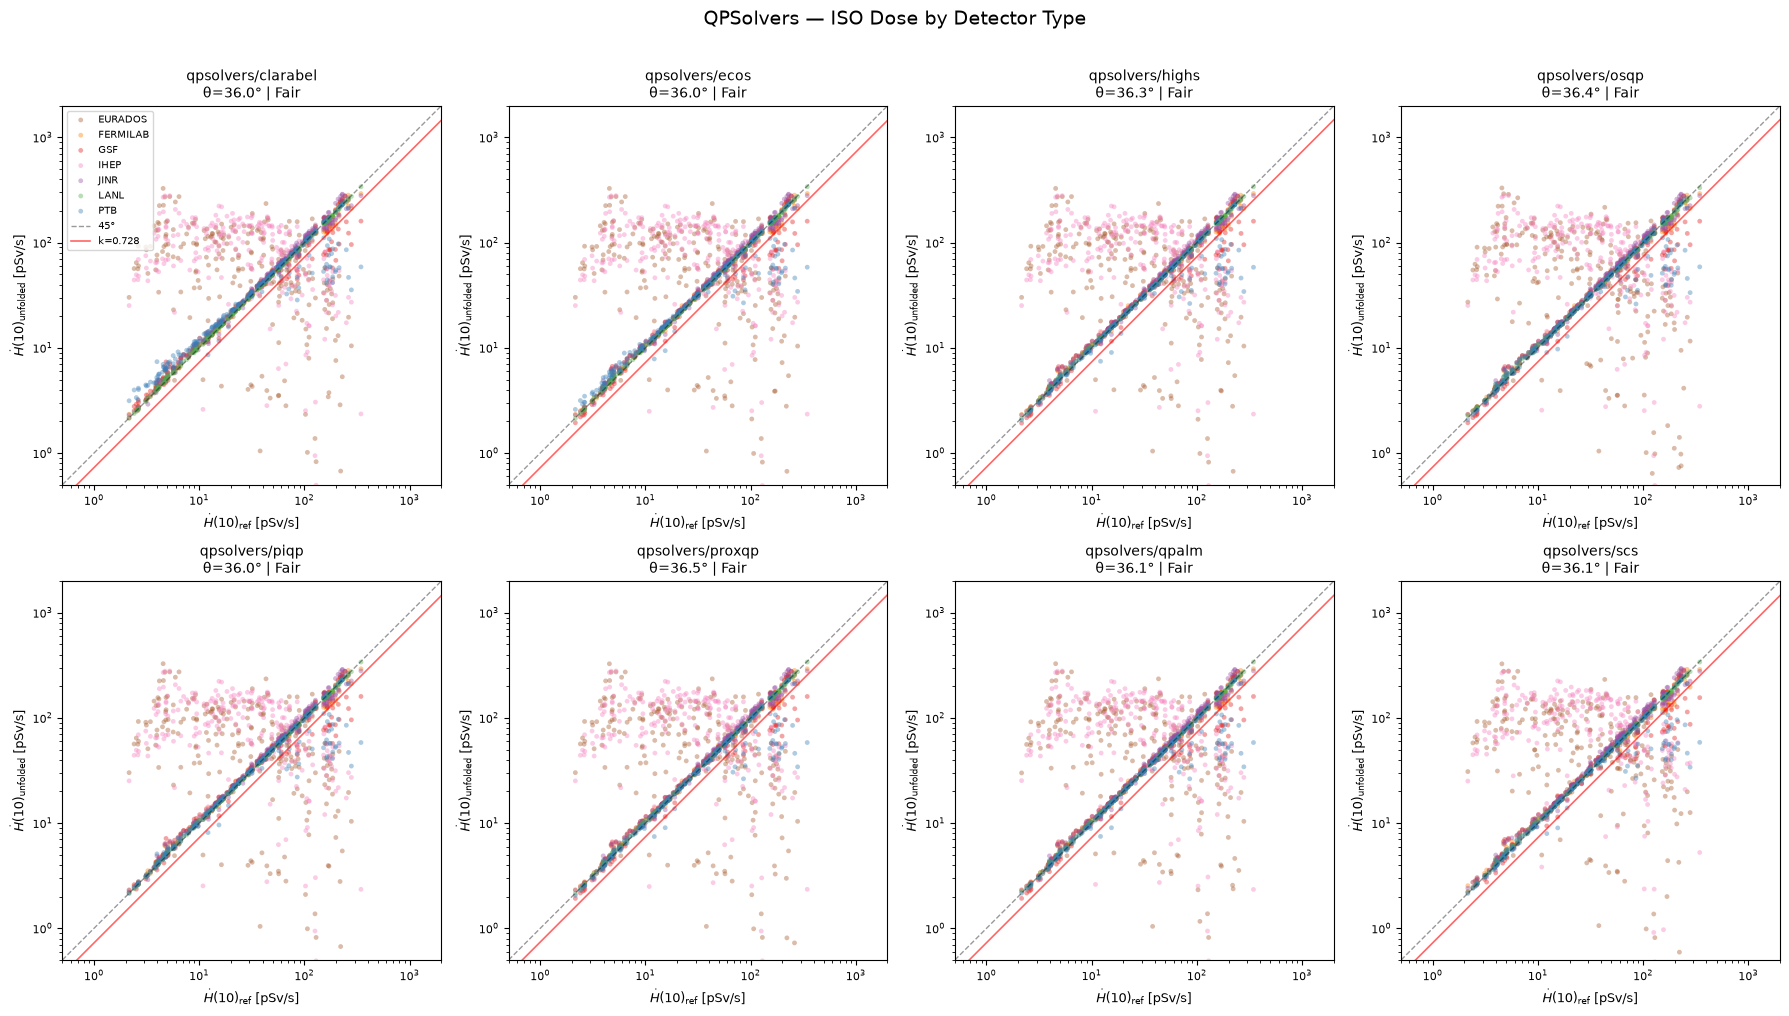

In [4]:
qp_solvers = sorted(ok[ok['solver_type'] == 'qpsolvers']['solver_name'].unique())
ncols = 4
nrows = (len(qp_solvers) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes_flat = np.array(axes).flatten()

for i, solver in enumerate(qp_solvers):
    ax = axes_flat[i]
    sdf = ok[(ok['solver_type'] == 'qpsolvers') & (ok['solver_name'] == solver) & (ok['geometry'] == 'ISO')]

    thetas = []
    for det in sorted(DETECTOR_COLORS.keys()):
        ddf = sdf[sdf['detector'] == det]
        if len(ddf) > 0:
            plot_scatter(ax, ddf['dose_ref'].values, ddf['dose_unfolded'].values,
                        DETECTOR_COLORS[det], det, alpha=0.4)
            k, theta, cls = fit_angle(ddf['dose_ref'].values, ddf['dose_unfolded'].values)
            thetas.append((det, theta, cls))

    lims = [0.5, 2000]
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal')
    ax.set_xlabel(r'$\dot{H}(10)_{\mathrm{ref}}$ [pSv/s]', fontsize=9)
    ax.set_ylabel(r'$\dot{H}(10)_{\mathrm{unfolded}}$ [pSv/s]', fontsize=9)
    
    # Compute overall angle
    k_all, theta_all, cls_all = fit_angle(sdf['dose_ref'].values, sdf['dose_unfolded'].values)
    add_diagonal(ax, k_all)
    ax.set_title(f'qpsolvers/{solver}\nθ={theta_all:.1f}° | {cls_all}', fontsize=10)
    ax.tick_params(labelsize=8)
    if i == 0:
        ax.legend(fontsize=7, loc='upper left')

for i in range(len(qp_solvers), len(axes_flat)):
    axes_flat[i].set_visible(False)

fig.suptitle('QPSolvers — ISO Dose by Detector Type', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### QPSolvers — Per-Detector Angle Table

In [5]:
qp_iso = ok[(ok['solver_type'] == 'qpsolvers') & (ok['geometry'] == 'ISO')]

rows = []
for solver in qp_solvers:
    for det in sorted(DETECTOR_COLORS.keys()):
        sdf = qp_iso[(qp_iso['solver_name'] == solver) & (qp_iso['detector'] == det)]
        k, theta, cls = fit_angle(sdf['dose_ref'].values, sdf['dose_unfolded'].values)
        rows.append({'solver': solver, 'detector': det, 'theta': theta, 'k': k, 'class': cls})

qp_table = pd.DataFrame(rows).pivot(index='solver', columns='detector', values='theta')
qp_table.style.format('{:.1f}°').background_gradient(cmap='RdYlGn_r', vmin=35, vmax=55, axis=None)

detector,EURADOS,FERMILAB,GSF,IHEP,JINR,LANL,PTB
solver,,,,,,,
clarabel,15.6°,43.9°,38.8°,20.7°,44.9°,44.7°,34.3°
ecos,15.6°,43.9°,38.7°,20.7°,44.9°,44.7°,34.0°
highs,16.5°,43.9°,38.7°,21.4°,44.9°,44.7°,33.8°
osqp,14.9°,43.9°,38.7°,23.4°,44.9°,44.5°,34.1°
piqp,15.6°,43.9°,38.8°,20.7°,44.9°,44.7°,34.0°
proxqp,16.5°,43.9°,38.7°,22.6°,44.9°,44.7°,33.8°
qpalm,15.6°,43.9°,38.7°,21.5°,44.9°,44.7°,33.8°
scs,15.6°,43.7°,38.6°,21.8°,45.2°,44.7°,33.9°


---
## 2. CVXPY — All Solvers × All Detectors

ISO dose scatter plots for each cvxpy solver. Colors = detector types.

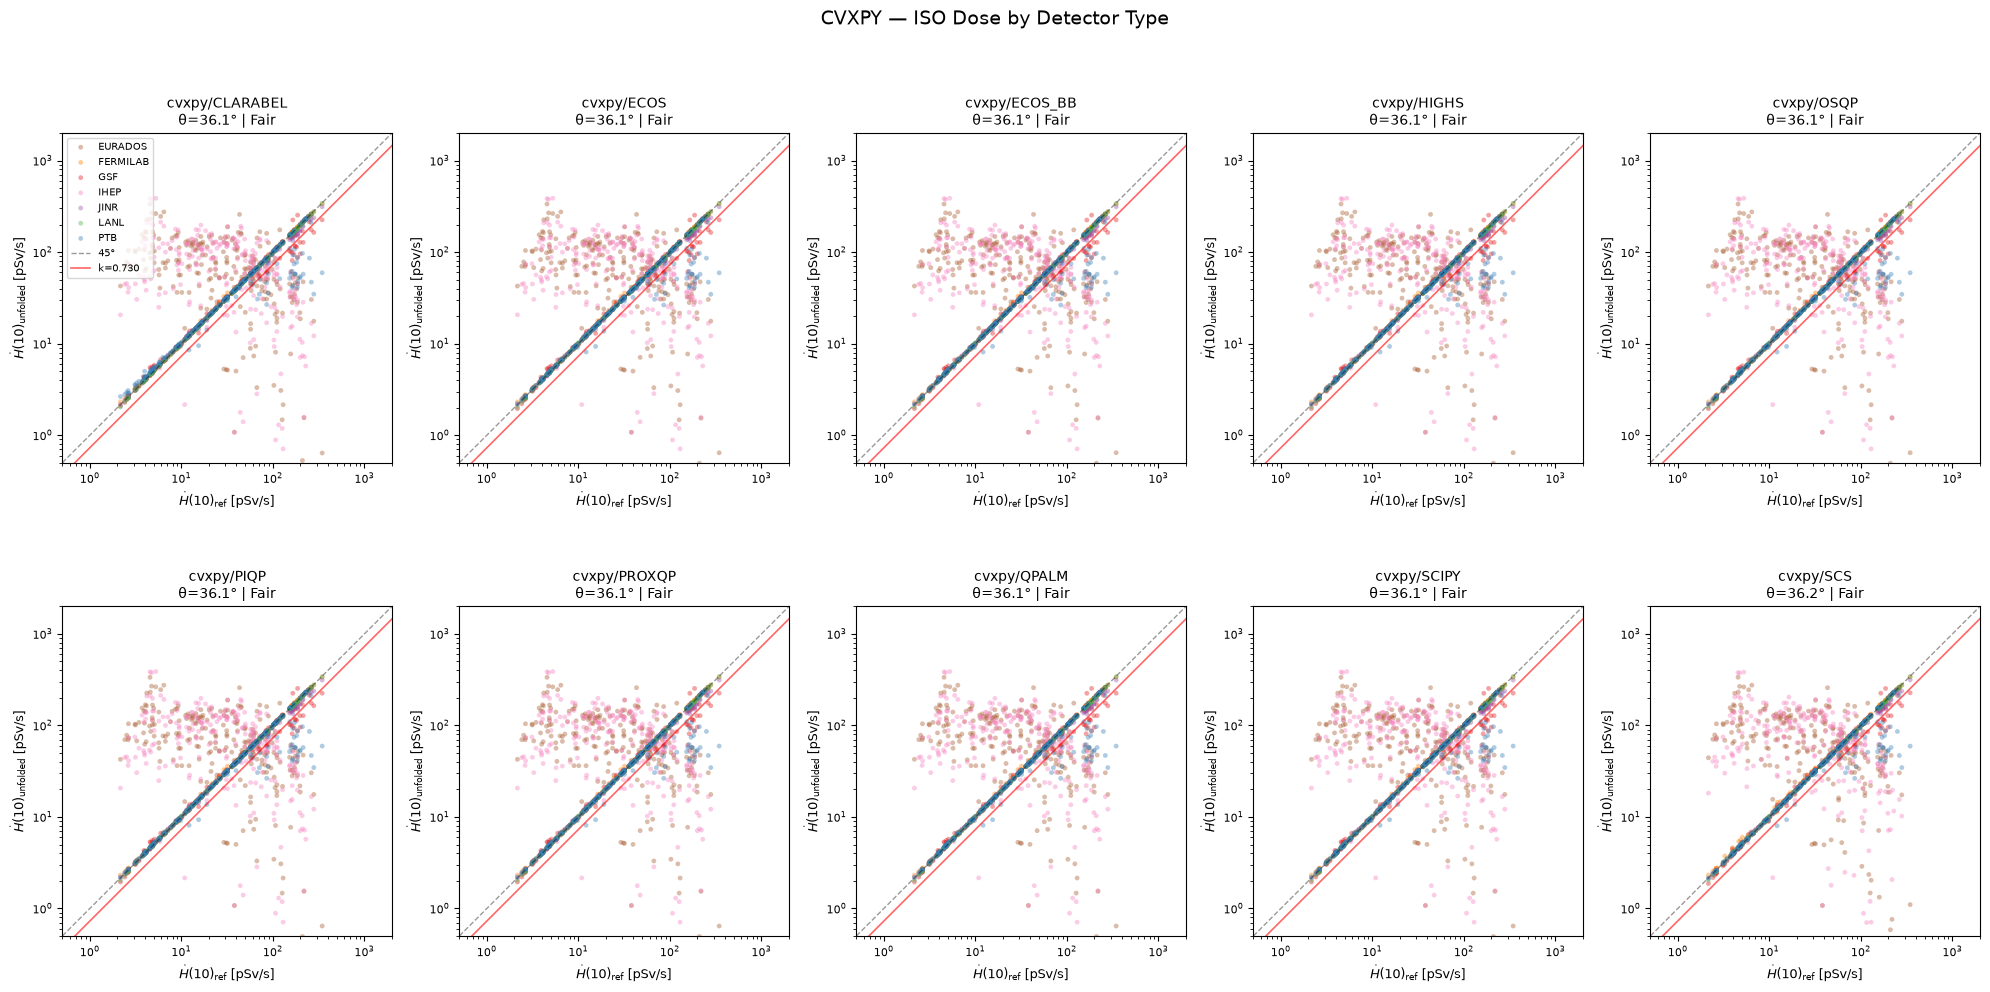

In [6]:
cv_solvers = sorted(ok[ok['solver_type'] == 'cvxpy']['solver_name'].unique())
ncols = 5
nrows = (len(cv_solvers) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 5 * nrows))
axes_flat = np.array(axes).flatten()

for i, solver in enumerate(cv_solvers):
    ax = axes_flat[i]
    sdf = ok[(ok['solver_type'] == 'cvxpy') & (ok['solver_name'] == solver) & (ok['geometry'] == 'ISO')]

    for det in sorted(DETECTOR_COLORS.keys()):
        ddf = sdf[sdf['detector'] == det]
        if len(ddf) > 0:
            plot_scatter(ax, ddf['dose_ref'].values, ddf['dose_unfolded'].values,
                        DETECTOR_COLORS[det], det, alpha=0.4)

    lims = [0.5, 2000]
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal')
    ax.set_xlabel(r'$\dot{H}(10)_{\mathrm{ref}}$ [pSv/s]', fontsize=9)
    ax.set_ylabel(r'$\dot{H}(10)_{\mathrm{unfolded}}$ [pSv/s]', fontsize=9)
    
    k_all, theta_all, cls_all = fit_angle(sdf['dose_ref'].values, sdf['dose_unfolded'].values)
    add_diagonal(ax, k_all)
    ax.set_title(f'cvxpy/{solver}\nθ={theta_all:.1f}° | {cls_all}', fontsize=10)
    ax.tick_params(labelsize=8)
    if i == 0:
        ax.legend(fontsize=7, loc='upper left')

for i in range(len(cv_solvers), len(axes_flat)):
    axes_flat[i].set_visible(False)

fig.suptitle('CVXPY — ISO Dose by Detector Type', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### CVXPY — Per-Detector Angle Table

In [7]:
cv_iso = ok[(ok['solver_type'] == 'cvxpy') & (ok['geometry'] == 'ISO')]

rows = []
for solver in cv_solvers:
    for det in sorted(DETECTOR_COLORS.keys()):
        sdf = cv_iso[(cv_iso['solver_name'] == solver) & (cv_iso['detector'] == det)]
        k, theta, cls = fit_angle(sdf['dose_ref'].values, sdf['dose_unfolded'].values)
        rows.append({'solver': solver, 'detector': det, 'theta': theta, 'k': k, 'class': cls})

cv_table = pd.DataFrame(rows).pivot(index='solver', columns='detector', values='theta')
cv_table.style.format('{:.1f}°').background_gradient(cmap='RdYlGn_r', vmin=35, vmax=55, axis=None)

detector,EURADOS,FERMILAB,GSF,IHEP,JINR,LANL,PTB
solver,,,,,,,
CLARABEL,17.1°,45.0°,41.0°,17.4°,43.6°,44.8°,33.9°
ECOS,17.1°,45.0°,41.0°,17.4°,43.6°,44.8°,33.8°
ECOS_BB,17.1°,45.0°,41.0°,17.4°,43.6°,44.8°,33.8°
HIGHS,17.1°,45.0°,41.0°,17.4°,43.6°,44.8°,33.8°
OSQP,17.1°,45.0°,41.0°,17.4°,43.6°,44.8°,33.8°
PIQP,17.1°,45.0°,41.0°,17.4°,43.6°,44.8°,33.8°
PROXQP,17.1°,45.0°,41.0°,17.4°,43.6°,44.8°,33.8°
QPALM,17.1°,45.0°,41.0°,17.4°,43.6°,44.8°,33.8°
SCIPY,17.1°,45.0°,41.0°,17.4°,43.6°,44.8°,33.8°


---
## 3. Heatmap — All Solver × Detector Combinations

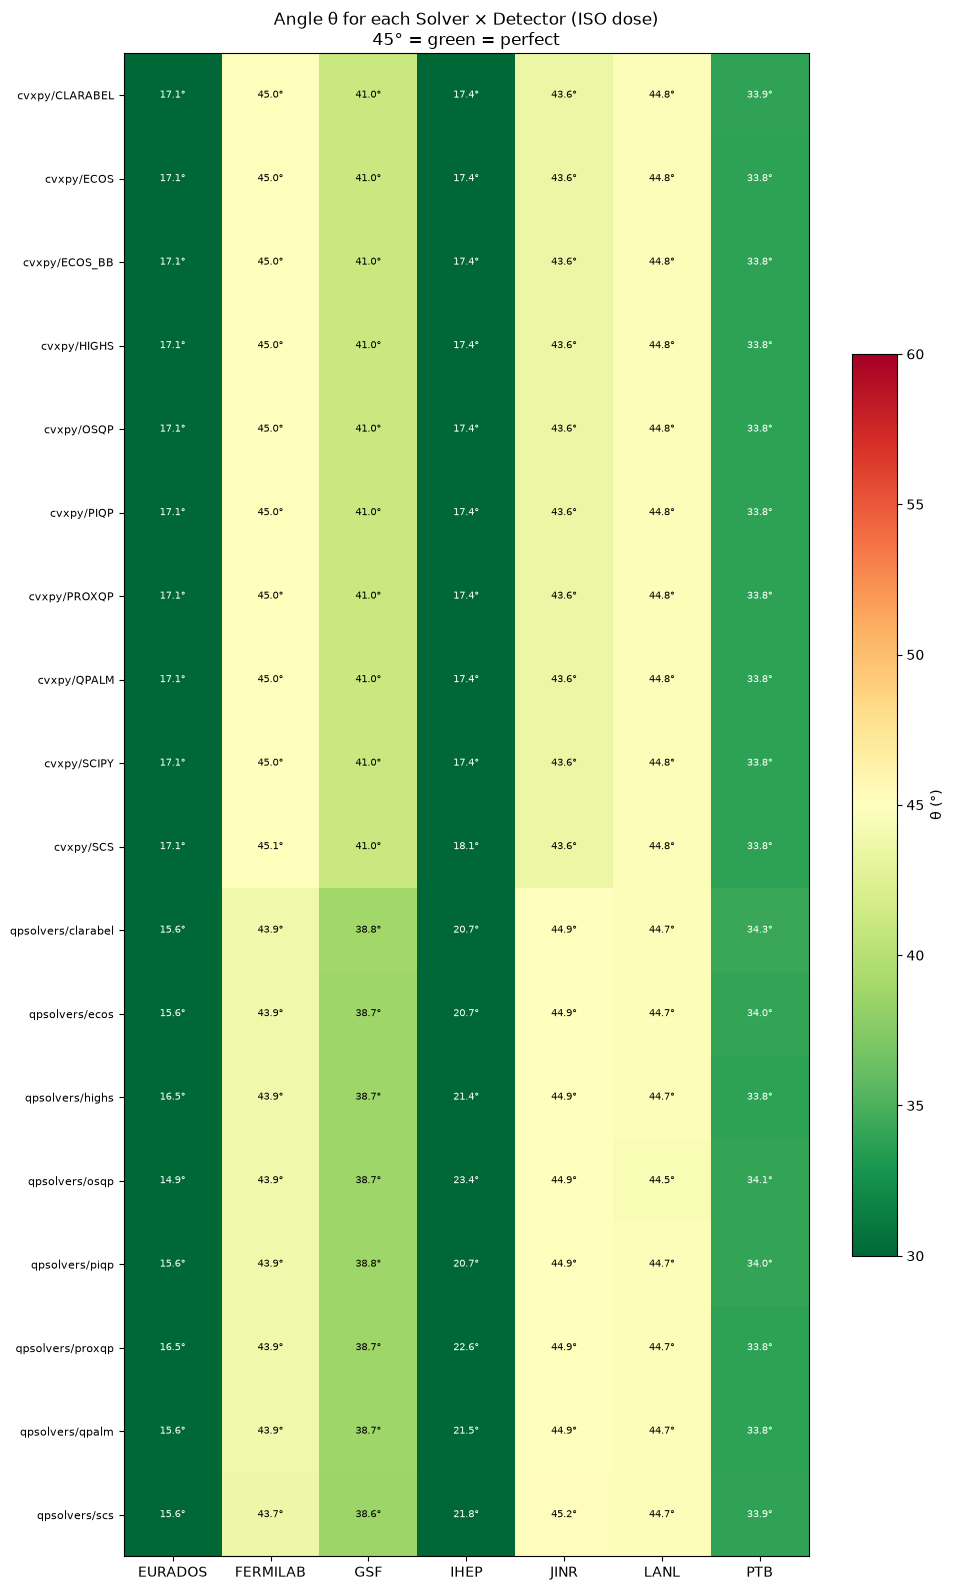

In [8]:
all_rows = []
for (st, sn, det), sdf in ok[ok['geometry'] == 'ISO'].groupby(['solver_type', 'solver_name', 'detector']):
    k, theta, cls = fit_angle(sdf['dose_ref'].values, sdf['dose_unfolded'].values)
    all_rows.append({'type': st, 'solver': sn, 'detector': det, 'theta': theta, 'k': k, 'class': cls})

all_df = pd.DataFrame(all_rows)
all_df['label'] = all_df['type'] + '/' + all_df['solver']

heatmap = all_df.pivot(index='label', columns='detector', values='theta')
heatmap = heatmap.reindex(columns=sorted(DETECTOR_COLORS.keys()))

fig, ax = plt.subplots(figsize=(10, 16))
im = ax.imshow(heatmap.values, cmap='RdYlGn_r', aspect='auto', vmin=30, vmax=60)
ax.set_xticks(range(len(heatmap.columns)))
ax.set_xticklabels(heatmap.columns, fontsize=10)
ax.set_yticks(range(len(heatmap.index)))
ax.set_yticklabels(heatmap.index, fontsize=8)

for i in range(len(heatmap.index)):
    for j in range(len(heatmap.columns)):
        val = heatmap.values[i, j]
        if np.isfinite(val):
            color = 'white' if val < 38 or val > 52 else 'black'
            ax.text(j, i, f'{val:.1f}°', ha='center', va='center', fontsize=7, color=color)

plt.colorbar(im, ax=ax, label='θ (°)', shrink=0.6)
ax.set_title('Angle θ for each Solver × Detector (ISO dose)\n45° = green = perfect', fontsize=12)
plt.tight_layout()
plt.show()

---
## 4. Per-Detector — All Solvers Comparison

For each detector, compare all solvers on one plot.

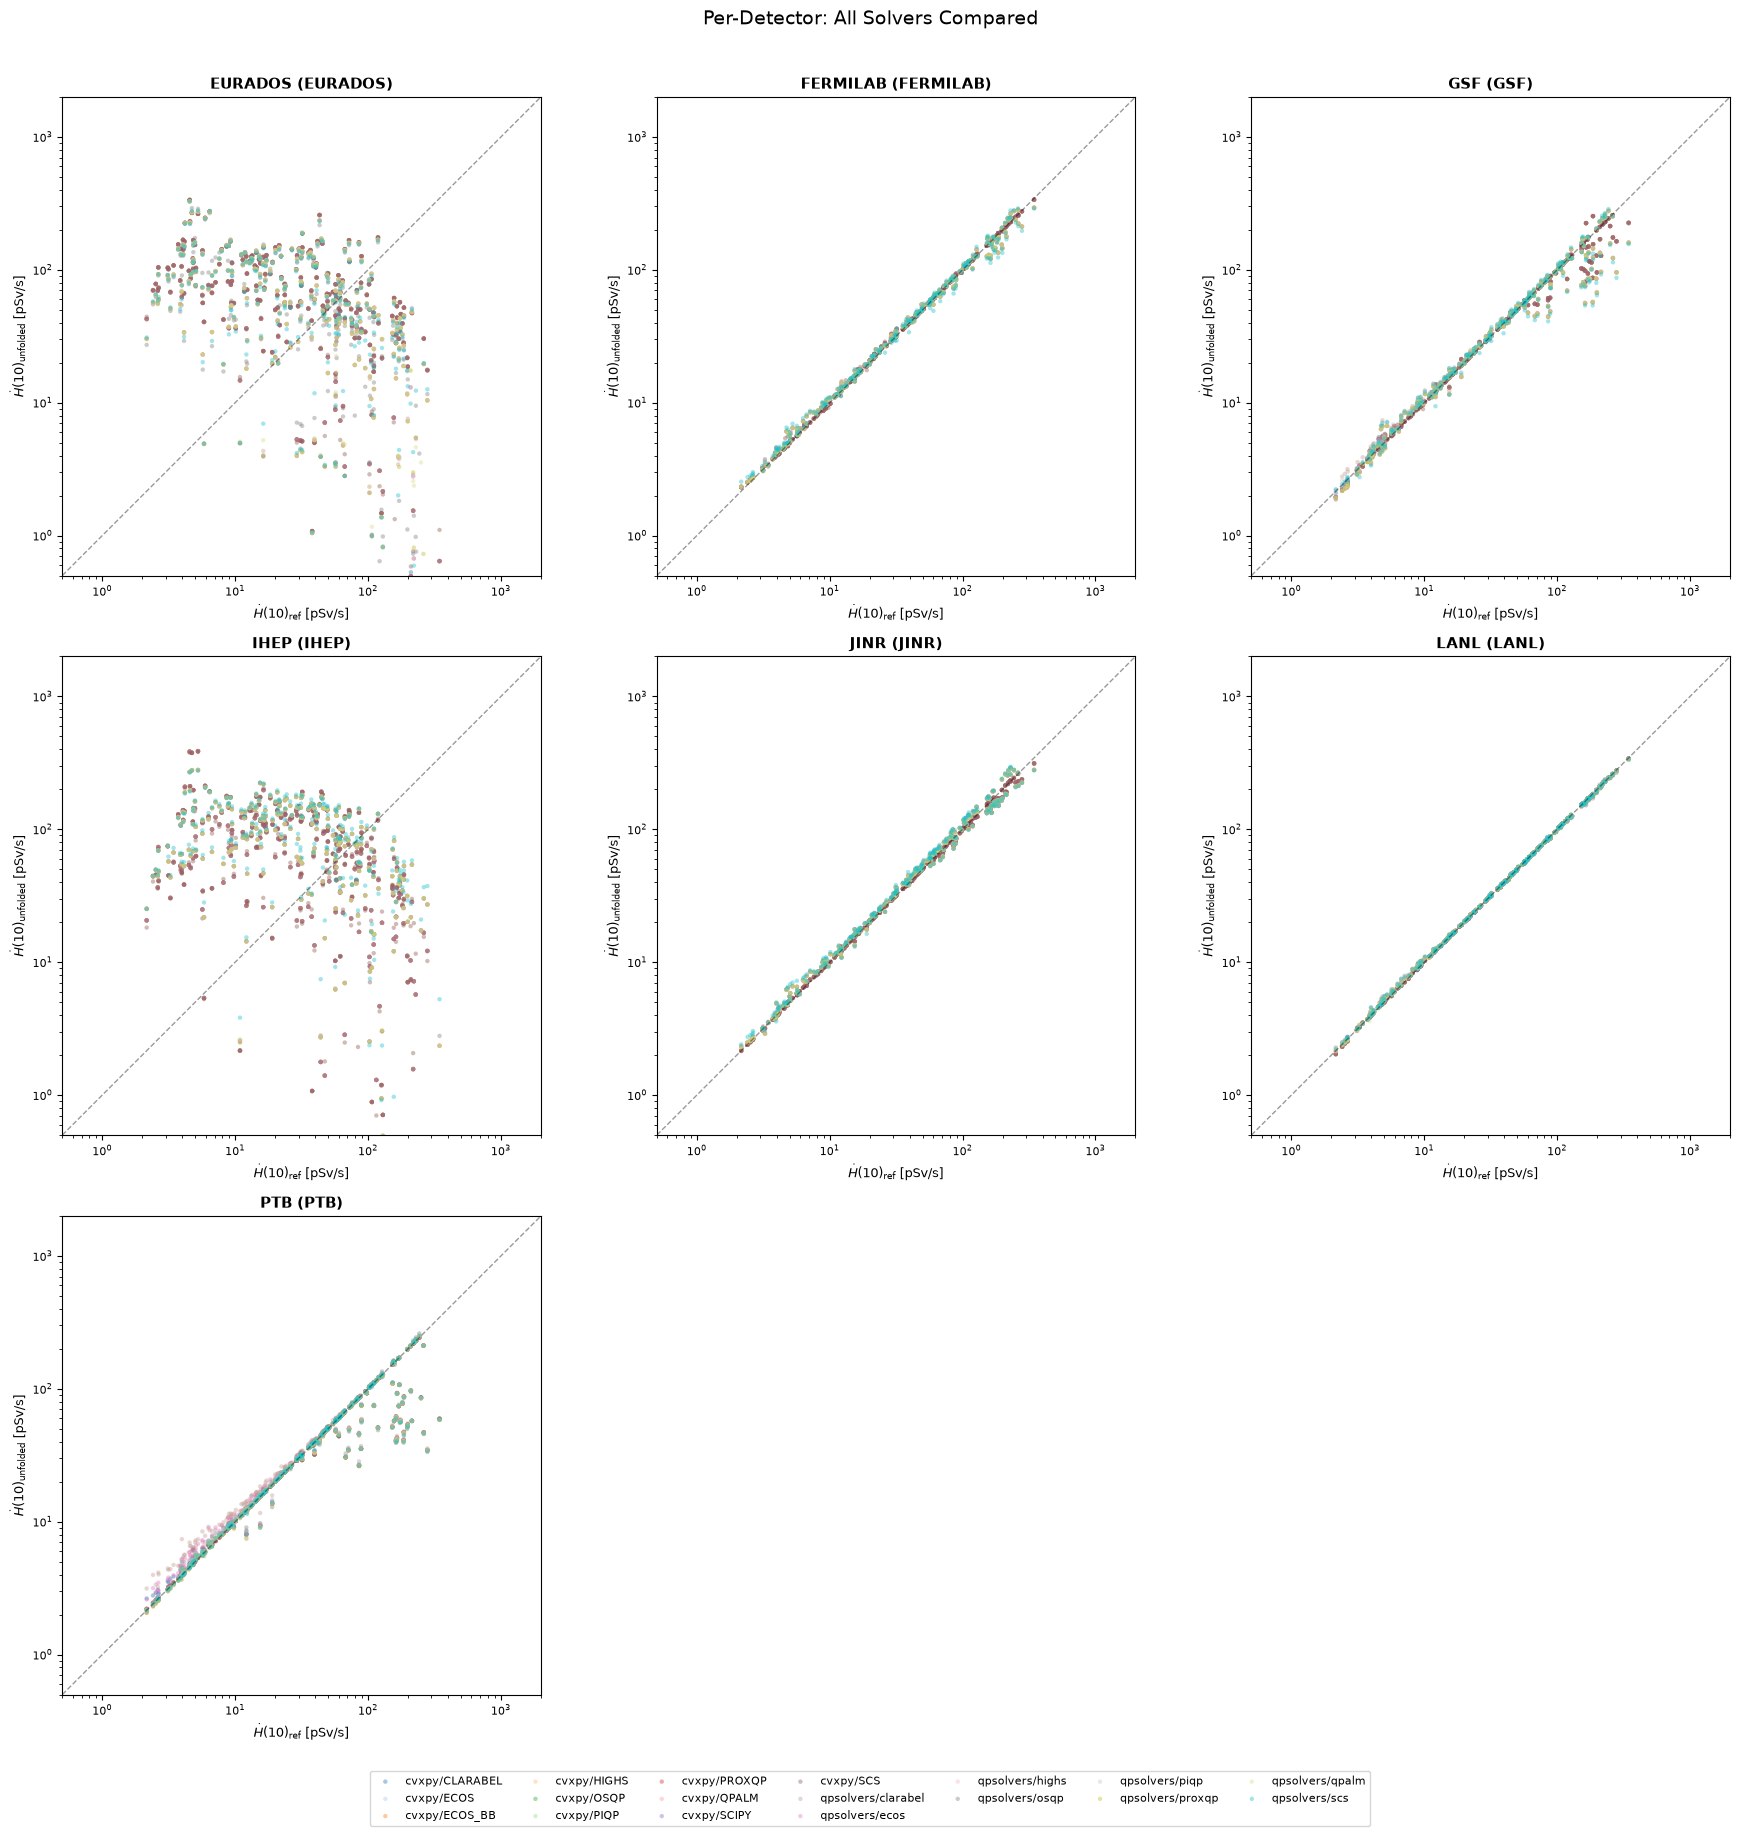

In [9]:
detectors = sorted(ok['detector'].unique())
all_solvers_list = sorted(all_df['label'].unique())
solver_cmap = plt.cm.tab20
solver_colors = {s: solver_cmap(i / len(all_solvers_list)) for i, s in enumerate(all_solvers_list)}

fig, axes = plt.subplots(3, 3, figsize=(18, 18))
axes_flat = axes.flatten()

for i, det in enumerate(detectors):
    ax = axes_flat[i]
    ddf = ok[(ok['detector'] == det) & (ok['geometry'] == 'ISO')]
    
    for label in all_solvers_list:
        sdf = ddf[ddf['solver_type'] + '/' + ddf['solver_name'] == label]
        if len(sdf) > 0:
            ax.scatter(sdf['dose_ref'], sdf['dose_unfolded'],
                      c=[solver_colors[label]], s=10, alpha=0.4, edgecolors='none', label=label)
    
    lims = [0.5, 2000]
    ax.plot(lims, lims, 'k--', lw=1, alpha=0.4)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal')
    ax.set_xlabel(r'$\dot{H}(10)_{\mathrm{ref}}$ [pSv/s]', fontsize=9)
    ax.set_ylabel(r'$\dot{H}(10)_{\mathrm{unfolded}}$ [pSv/s]', fontsize=9)
    ax.set_title(f'{det} ({ddf["detector"].iloc[0] if len(ddf) > 0 else ""})', fontsize=11, fontweight='bold')
    ax.tick_params(labelsize=8)

# Hide unused subplots
for i in range(len(detectors), len(axes_flat)):
    axes_flat[i].set_visible(False)

# Add legend
handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=7, fontsize=8, frameon=True)
fig.suptitle('Per-Detector: All Solvers Compared', fontsize=14, y=1.01)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

---
## 5. Overestimation / Underestimation Analysis

In [10]:
iso_data = ok[ok['geometry'] == 'ISO'].copy()
iso_data['ratio'] = iso_data['dose_unfolded'] / iso_data['dose_ref']
iso_data['label'] = iso_data['solver_type'] + '/' + iso_data['solver_name']

# Per detector: mean ratio across all solvers
print('=== Mean dose ratio by detector (across all solvers) ===')
det_stats = iso_data.groupby('detector').agg(
    mean_ratio=('ratio', 'mean'),
    std_ratio=('ratio', 'std'),
    min_ratio=('ratio', 'min'),
    max_ratio=('ratio', 'max'),
    n_under=('ratio', lambda x: (x < 0.9).sum()),
    n_over=('ratio', lambda x: (x > 1.1).sum()),
).round(3)
print(det_stats.to_string())

print('\n=== Mean dose ratio by solver (across all detectors) ===')
sol_stats = iso_data.groupby('label').agg(
    mean_ratio=('ratio', 'mean'),
    std_ratio=('ratio', 'std'),
    min_ratio=('ratio', 'min'),
    max_ratio=('ratio', 'max'),
).round(3)
print(sol_stats.sort_values('mean_ratio', key=abs).to_string())

=== Mean dose ratio by detector (across all solvers) ===
          mean_ratio  std_ratio  min_ratio  max_ratio  n_under  n_over
detector                                                              
EURADOS        6.980     11.758      0.000     73.944     1743    2607
FERMILAB       1.014      0.057      0.670      1.377      157     238
GSF            0.975      0.146      0.291      1.520      605     311
IHEP           6.831     11.053      0.000     84.648     1542    2815
JINR           1.015      0.074      0.800      1.356      342     517
LANL           1.001      0.019      0.919      1.148        0      11
PTB            0.929      0.222      0.120      1.862      721     164

=== Mean dose ratio by solver (across all detectors) ===
                    mean_ratio  std_ratio  min_ratio  max_ratio
label                                                          
qpsolvers/qpalm          2.661      6.352        0.0     72.147
qpsolvers/highs          2.663      6.362        0.0  

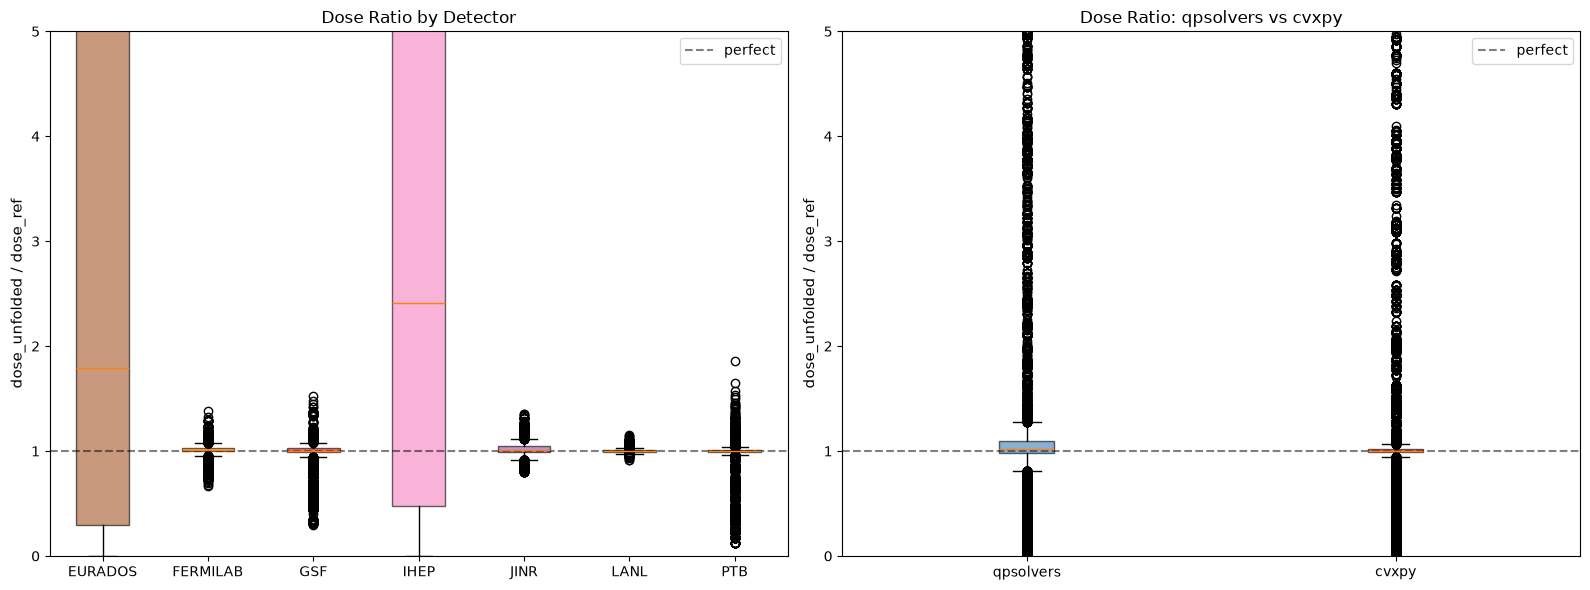

In [11]:
# Box plot of ratios by detector
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# By detector
det_data = [iso_data[iso_data['detector'] == d]['ratio'].values for d in sorted(DETECTOR_COLORS.keys())]
bp1 = axes[0].boxplot(det_data, tick_labels=sorted(DETECTOR_COLORS.keys()), patch_artist=True)
for patch, det in zip(bp1['boxes'], sorted(DETECTOR_COLORS.keys())):
    patch.set_facecolor(DETECTOR_COLORS[det])
    patch.set_alpha(0.6)
axes[0].axhline(y=1.0, color='k', ls='--', alpha=0.5, label='perfect')
axes[0].set_ylabel('dose_unfolded / dose_ref', fontsize=11)
axes[0].set_title('Dose Ratio by Detector', fontsize=12)
axes[0].set_ylim(0, 5)
axes[0].legend()

# By solver type
qp_data = iso_data[iso_data['solver_type'] == 'qpsolvers']['ratio'].values
cv_data = iso_data[iso_data['solver_type'] == 'cvxpy']['ratio'].values
bp2 = axes[1].boxplot([qp_data, cv_data], tick_labels=['qpsolvers', 'cvxpy'], patch_artist=True)
bp2['boxes'][0].set_facecolor('#377eb8')
bp2['boxes'][0].set_alpha(0.6)
bp2['boxes'][1].set_facecolor('#e41a1c')
bp2['boxes'][1].set_alpha(0.6)
axes[1].axhline(y=1.0, color='k', ls='--', alpha=0.5, label='perfect')
axes[1].set_ylabel('dose_unfolded / dose_ref', fontsize=11)
axes[1].set_title('Dose Ratio: qpsolvers vs cvxpy', fontsize=12)
axes[1].set_ylim(0, 5)
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 6. EURADOS Caveat

**EURADOS response functions have a maximum energy of 20 MeV.** The 7 highest-energy bins
(25.1–398 MeV) from the IAEA Compendium reference spectra are extrapolated to 0.
This means EURADOS results **systematically underestimate dose** for spectra with
significant high-energy content (>20 MeV), because the detector cannot "see" those neutrons.

EURADOS results should be interpreted with this limitation in mind.

---
## 7. Summary

### Best Solver × Detector Combinations

| Rank | Solver | Detector | θ (°) | Classification |
|------|--------|----------|-------|----------------|

In [12]:
ranked = all_df.sort_values('theta', key=lambda s: (s - 45).abs()).reset_index(drop=True)
ranked.index += 1
top20 = ranked.head(20)[['type', 'solver', 'detector', 'theta', 'k', 'class']]
top20.columns = ['Type', 'Solver', 'Detector', 'θ (°)', 'k', 'Classification']
top20.style.format({'θ (°)': '{:.2f}', 'k': '{:.4f}'})

,Type,Solver,Detector,θ (°),k,Classification
1,cvxpy,QPALM,FERMILAB,45.03,1.0011,Excellent
2,cvxpy,OSQP,FERMILAB,45.03,1.0011,Excellent
3,cvxpy,PIQP,FERMILAB,45.03,1.0011,Excellent
4,cvxpy,ECOS_BB,FERMILAB,45.03,1.0011,Excellent
5,cvxpy,PROXQP,FERMILAB,45.03,1.0011,Excellent
6,cvxpy,ECOS,FERMILAB,45.03,1.0011,Excellent
7,cvxpy,SCIPY,FERMILAB,45.03,1.0011,Excellent
8,cvxpy,HIGHS,FERMILAB,45.03,1.0011,Excellent
9,cvxpy,CLARABEL,FERMILAB,45.03,1.0011,Excellent
10,cvxpy,SCS,FERMILAB,45.06,1.0021,Excellent


### Worst Combinations

In [13]:
worst20 = ranked.tail(20).iloc[::-1][['type', 'solver', 'detector', 'theta', 'k', 'class']]
worst20.columns = ['Type', 'Solver', 'Detector', 'θ (°)', 'k', 'Classification']
worst20.style.format({'θ (°)': '{:.2f}', 'k': '{:.4f}'})

,Type,Solver,Detector,θ (°),k,Classification
126,qpsolvers,osqp,EURADOS,14.88,0.2658,Poor
125,qpsolvers,qpalm,EURADOS,15.59,0.2790,Poor
124,qpsolvers,clarabel,EURADOS,15.60,0.2792,Poor
123,qpsolvers,ecos,EURADOS,15.60,0.2792,Poor
122,qpsolvers,piqp,EURADOS,15.60,0.2793,Poor
121,qpsolvers,scs,EURADOS,15.61,0.2793,Poor
120,qpsolvers,highs,EURADOS,16.46,0.2954,Poor
119,qpsolvers,proxqp,EURADOS,16.48,0.2959,Poor
118,cvxpy,OSQP,EURADOS,17.10,0.3077,Poor
117,cvxpy,ECOS,EURADOS,17.10,0.3077,Poor


### Key Findings

1. **Detector choice dominates solver choice** — all cvxpy solvers give identical angles for
   the same detector (e.g., cvxpy/CLARABEL + LANL = cvxpy/ECOS + LANL = 44.8°).
2. **Best combinations** (Excellent, θ ≈ 45°):
   - FERMILAB: 45.0° (cvxpy) / 43.9° (qpsolvers)
   - LANL: 44.8° (cvxpy) / 44.7° (qpsolvers)
   - JINR: 43.6° (cvxpy) / 44.9° (qpsolvers)
3. **EURADOS severely underestimates** (θ ≈ 17°) due to 20 MeV energy ceiling.
4. **PTB and IHEP show systematic underestimation** — PTB θ ≈ 34°, IHEP θ ≈ 17-23°.
5. **qpsolvers vs cvxpy** — cvxpy solvers are slightly more accurate (45.0° vs 43.9° for FERMILAB)
   but differences are within 1° for most combinations.
6. **SCS cvxpy is slightly worse** for IHEP (18.1° vs 17.4° for other cvxpy solvers).